# Discourse Lab — reference notebook

A guided tour of the toolbox, in build order (see `TODO.txt` and
`discourse-lab-dev.md` §6). Each section is runnable on its own once the
previous one has executed — copy a section into your own notebook as a
starting point.

Dynamics are numeric; language (the last section) is an offline pass over
already-decided numeric state and never runs inside the simulation loop.


## Running in Google Colab

Open this notebook in Colab (GitHub tab -> `lrodeck/Network-Simulation`,
branch `claude/todos-continuation-tupw4f` -> `notebooks/demo.ipynb`, or File ->
Upload notebook), then run the cell below first — it installs the package
straight from this repo (not on PyPI, and not yet merged to `main`, hence the
pinned branch) and is a no-op outside Colab. Everything after it is
unchanged: `workspace()` already resolves to `/content/dlab` under Colab
automatically.


In [1]:
import sys

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    %pip install -q "git+https://github.com/lrodeck/Network-Simulation.git@claude/todos-continuation-tupw4f"


In [2]:
import os
import warnings
import dataclasses

import numpy as np
import polars as pl

from IPython.display import Markdown, display

from discourse_lab.config import Config
from discourse_lab.io.workspace import figures_dir, tables_dir
from discourse_lab.viz import tables  # needs the optional extra: pip install -e ".[viz]"


def show(df, precision=3):
    """Render a polars frame as a Markdown table.

    `show(df)` emits Markdown into a plain-text stream,
    where the notebook shows it as pipes and dashes. Same table, rendered.
    """
    display(Markdown(tables.to_markdown(df, precision=precision)))

# A scratch workspace so this notebook never touches a real ~/dlab.
os.environ["DLAB_HOME"] = os.path.join(os.getcwd(), "dlab_demo")

# The demo population/tick counts below are deliberately tiny for speed, which
# makes the cascade size/depth caps bind far more often than they would at a
# realistic scale — expected here, not a sign of a bug. Silence the warning
# for this notebook; leave it on when calibrating a real run.
warnings.filterwarnings("ignore", message="cascade:")

SEED = 0
rng = np.random.default_rng(SEED)


## 1. Config — and the world it describes

`scenario_config()` attaches a packaged scenario. That is what gives the run a
vocabulary: named ideological axes with named poles, and named topics. Without
it every output below says `stance_0` instead of "provision: leans market".

It refuses to change stance dimensionality silently, because a scenario
overrides `population.stance_dims` and D decides which mechanisms are even
measurable — the homophily agreement effect is t=+2.46 at D=1 and t=-0.05 at
D=3.

In [3]:
from discourse_lab.data import packaged_scenarios, scenario_config

print("packaged scenarios:", packaged_scenarios())

cfg = scenario_config(dataclasses.replace(
    Config(),
    # n_topics must cover the scenario's named topics, or Config refuses
    population=dataclasses.replace(Config().population, n_users=600, n_topics=8),
    # drift defaults to "full"; off here so sections 1-9 isolate the dynamics
    # this notebook is demonstrating. Turned back on in §10.
    dynamics=dataclasses.replace(Config().dynamics, n_ticks=30, kernel="homophily",
                                 ranker="affinity", drift="none"),
))
print("config hash:", cfg.hash())
print("stance dims:", cfg.stance_dims())

# `cfg` on its own is a 900-character dataclass repr on one line. Same fields,
# one row each, with everything this run moved off the defaults flagged.
config = tables.config_table(cfg)
show(config.filter(config[""] == "changed").drop(""))

packaged scenarios: ['default']
config hash: 02cd84e4d949b4a3401849af7dfddb50
stance dims: 3


| Section | Field | Value |
| --- | --- | --- |
| population | n_users | 600 |
| dynamics | n_ticks | 30 |
| dynamics | ranker | affinity |
| dynamics | drift | none |
| scenario | stance_axes | 3 entries |
| scenario | topic_names | immigration, housing, climate, healthcare, … |

## 2. Population

Archetype mixture over a correlated Gaussian latent, transformed to target
marginals by a Gaussian copula (spec §2.1). `cached_population` reuses a
prior draw for this exact population sub-config + seed.


In [4]:
from discourse_lab.population import cached_population

pop = cached_population(cfg, seed=SEED, rng=rng)
print(f"{len(pop.trait_names)} traits x {cfg.population.n_users} users")
print("archetypes:", sorted(set(pop.archetype_names)))

archetype_of_user = np.array(pop.archetype_names)[pop.archetype_labels]
pl.DataFrame(
    {
        "archetype": archetype_of_user,
        "activity": pop.X_used[:, pop.trait_names.index("activity")],
        "prominence": pop.X_used[:, pop.trait_names.index("prominence")],
        "contrarianism": pop.X_used[:, pop.trait_names.index("contrarianism")],
    }
).group_by("archetype").agg(pl.all().mean()).sort("archetype")


31 traits x 600 users
archetypes: ['firebrand', 'institution', 'lurker', 'newcomer', 'poster']


archetype,activity,prominence,contrarianism
str,f64,f64,f64
"""firebrand""",3.117258,1.590307,0.483492
"""institution""",3.027089,11.923892,0.284267
"""lurker""",0.826273,1.582057,0.251026
"""newcomer""",3.859704,1.867448,0.269495
"""poster""",12.526686,1.797493,0.277725


## 3. Graph

`latent_space` (the default) connects users by homophily in stance/topic
space plus a preferential-attachment term on prominence, calibrated by
bisection to hit `mean_degree`. Swappable for `sbm`, `configuration_model`,
or `barabasi_albert` via `cfg.graph.generator` — each is a useful null model
for isolating what homophily itself contributes.


In [5]:
from discourse_lab.network import cached_graph
from discourse_lab.network.measures import degree_sequence, global_clustering

graph = cached_graph(cfg, seed=SEED, pop=pop, rng=rng)
deg = degree_sequence(graph.csr)
print(f"mean degree: {deg.mean():.1f} (target {cfg.graph.mean_degree})")
print(f"clustering coefficient: {global_clustering(graph.csr):.3f}")


mean degree: 40.2 (target 40.0)
clustering coefficient: 0.257


## 4. The world configuration, read as a world

A config hash and a JSON dump say nothing about *what world this is*. The
scenario names three cleavages and their poles; the population declares
archetypes with stance offsets and a correlation structure over traits. Those
choices are as much a result as the outcome table is — an intervention that
looks protective in a world with one dominant camp may not be in a world with
three.

`fig_trait_correlations` shows the correlations the population *actually* has,
not the ones requested: archetype offsets add between-group covariance on top
of `correlation_pairs`, so an asked-for 0.30 can arrive as 0.49. The library
warns when composition moves a requested pair materially.

| Property | Requested | Realised |
| --- | --- | --- |
| scenario | default |  |
| stance axes | 3 | provision, openness, institutional trust |
| topics | 8 | immigration, housing, climate, healthcare, policing, taxation, education, media trust |
| users | 600 |  |
| graph | latent_space | mean degree 40 |
| ranker | affinity |  |
| kernel | homophily |  |
| axis: provision | market -> state |  |
| axis: openness | closed -> open |  |
| axis: institutional trust | distrust -> trust |  |
| trait correlations | none (identity) | strongest activity x reply_prop = +0.28 |

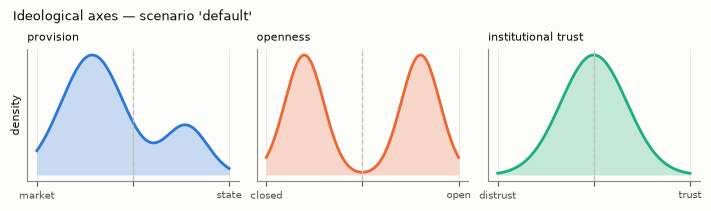

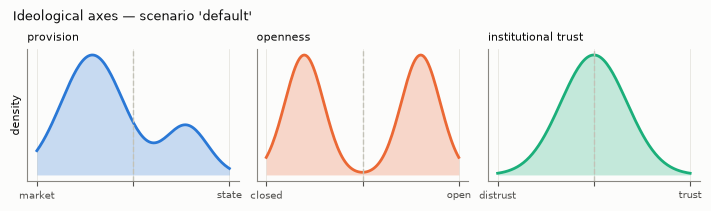

In [6]:
from discourse_lab.viz import fig_archetypes, fig_scenario_axes, fig_trait_correlations

world = tables.world_table(cfg, pop=pop)
show(world)

fig_scenario_axes(cfg)

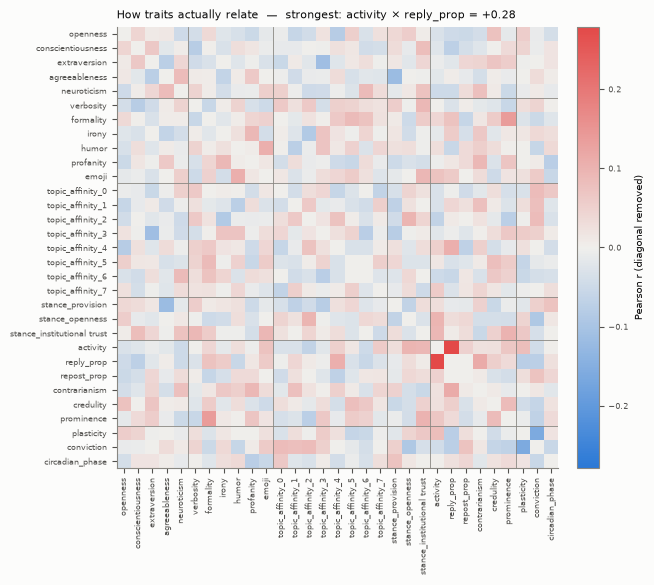

In [7]:
fig_trait_correlations(pop)

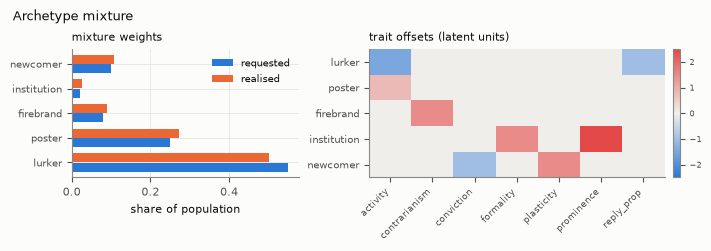

In [8]:
fig_archetypes(cfg, pop)

## 5. Stance editor widget

Draw a population's stance distribution by hand; the sampler preview shows
exactly what a copula draw from that curve looks like. Autosaves to
`scenarios/<name>.json` in the same schema `ScenarioConfig.from_editor_json`
reads, so a drawn scenario plugs directly back into a `Config`.


In [9]:
from discourse_lab.widgets import StanceEditorWidget

stance_editor = StanceEditorWidget(name="demo")
stance_editor


## 6. Running the simulation

`run_iter(cfg, seed)` is the generator core — timing, generation, exposure,
reaction, cascades, perception, and the discourse-state update, one tick at a
time (drift is off in this `cfg`; see §10). `cached_run`/`run` collect it
into a persisted, parquet-backed run directory.


In [10]:
from discourse_lab.runner import cached_run, load_run

# persist=... opts into the raw tables. Without "posts" the §5.1 facts below
# cannot be computed at all: per-post engagement, cascade roots and depths all
# live there, not in the per-tick metrics.
run_dir = cached_run(cfg, seed=SEED, persist=("posts", "engagements"))
handle = load_run(cfg, seed=SEED)
metrics = handle.metrics()
print("run dir:", os.path.relpath(run_dir))
metrics.select(["t", "n_posts", "n_replies", "n_exposures", "attention_gini", "r_eff"]).tail(5)

run dir: dlab_demo/runs/02cd84e4d949b4a3401849af7dfddb50/0


t,n_posts,n_replies,n_exposures,attention_gini,r_eff
i64,f64,f64,f64,f64,f64
25,20.0,0.0,2847.0,0.54771,0.046365
26,23.0,1.0,2878.0,0.562165,0.080612
27,26.0,2.0,2891.0,0.586749,0.046005
28,40.0,2.0,2757.0,0.627679,0.042075
29,42.0,0.0,2804.0,0.597594,0.11127


In [11]:
# Two different attention Ginis, and they do not agree.
#
#   metrics.parquet:attention_gini  rolling, over posts still active this tick
#   posts.parquet                   lifetime engagement total per post
#
# spec §5.1's 0.8-0.95 target is about the second. Reporting the first against
# that range compares different quantities, which is what this cell used to do.
from discourse_lab.measures import gini

rolling = float(metrics["attention_gini"].drop_nulls().mean())
lifetime = float(gini(handle.posts()["engagement_count"].to_numpy().astype(float)))
print(f"rolling (per tick, active posts): {rolling:.3f}")
print(f"lifetime (per post, spec §5.1):   {lifetime:.3f}")

rolling (per tick, active posts): 0.582
lifetime (per post, spec §5.1):   0.522


## 7. Run monitor widget (live)

Consumes `run_iter` directly and plots measures as ticks complete — the
salience/agreement pair, bubble index, attention Gini, R_eff — so a config's
fate is visible within twenty ticks rather than only at the end.


In [12]:
from discourse_lab.runner import run_iter
from discourse_lab.semantics import describe_state, lexicon_for
from discourse_lab.widgets import RunMonitorWidget

# narrate=True computes a per-tick summary; cfg gives the widget the
# vocabulary to render it. Both are needed — without either the panel stays
# hidden and this is still a chart widget.
monitor = RunMonitorWidget(cfg=cfg)
states = []
for state in run_iter(cfg, seed=SEED + 1, narrate=True):
    monitor.push(state)
    states.append(state)
monitor

In [13]:
# the same sentence, outside the widget — greppable in a log, and the reason a
# 500-tick run is readable rather than a wall of sparklines
lex = lexicon_for(cfg)
for state in states[::10]:
    print(describe_state(state.summary, lex), end="\n\n")

t=0: attention on housing (30%), immigration (20%). On housing the market pole of provision leads (|σ|=0.03, steady). On immigration the market pole of provision leads (|σ|=0.04, steady). Population is bimodal (0.75); the two halves sit 1.19 apart. 38% of engagements cross camps, 0% of them hostile.

t=10: attention on housing (17%), policing (13%). On housing the market pole of provision leads (|σ|=0.25, hardening). On policing the market pole of provision leads (|σ|=0.23, hardening). Population is bimodal (0.75); the two halves sit 1.19 apart. 30% of engagements cross camps, 2% of them hostile.

t=20: attention on healthcare (17%), policing (16%). On healthcare the market pole of provision leads (|σ|=0.21, hardening). On policing the market pole of provision leads (|σ|=0.22, softening). Population is bimodal (0.75); the two halves sit 1.19 apart. 31% of engagements cross camps, 2% of them hostile.



## 8. Post-run metrics — the spec §5.1 calibration table

Computed from the run's own persisted posts and engagements, not from
synthetic data.

**This demo runs a deliberately tiny population**, and several of these facts
are scale-dependent — clustering against a degree-matched null measures ~1.8
here but 3.3 at 2000 users and 5.1 at 3000. Read the failures below as "this
demo is small", not as "the model misses them". The table also marks rows it
will not grade: a fact the spec quotes no target for, and the engagement
exponent whenever the tail is not a power law, where the fitted value depends
on where `x_min` lands rather than on the model.

In [14]:
from discourse_lab.metrics import stylized_facts_from_run

report = stylized_facts_from_run(handle, graph=graph, pop=pop)
facts = tables.stylized_facts_table(report)
show(facts)

| Fact | Value | Target | Status |
| --- | --- | --- | --- |
| Engagement per post (power-law alpha) — not a power law | 2.657 | 2-3 | n/a |
| Cascade size (share of singletons) | 0.860 | 0.9-1 | FAIL |
| Thread depth (mean, branched cascades) | 1.159 | 1.5-3 | FAIL |
| Attention Gini (lifetime, per post) | 0.522 | 0.8-0.95 | FAIL |
| Posting volume Gini | 0.712 | 0.7-0.9 | pass |
| Reciprocity | 0.381 | 0.2-0.4 | pass |
| Clustering vs degree-matched null | 1.674 | >= 3 | FAIL |
| Inter-cluster interaction rate | 0.279 | 0-0.33 | pass |
| Hostility given cross-cluster contact | 0.021 | -- | n/a |

## 9. Experiment 1 — kernel/ranker sweep vs. null

Every effect is measured against a matched `kernel="null"` run (same
population, graph, activity). Kept tiny here (2 kernels x 1 ranker x 3
seeds); bump `seeds` to 10+ for anything you'd actually report.


In [15]:
from discourse_lab.experiments import build_experiment1, run_experiment1, summarize_experiment1

# spec §4.4: "Minimum 10 seeds, and report distributions rather than points.
# This is the single most common way simulation studies of this kind go wrong."
# Three seeds here only to keep the demo quick — do not read an effect off it.
cells_exp1 = build_experiment1(cfg, kernels=("homophily", "bandwagon"), rankers=("affinity",))
rows = run_experiment1(cells_exp1, seeds=[0, 1, 2])
summarize_experiment1(rows)

kernel,ranker,attention_gini_effect_mean,bubble_index_effect_mean,r_eff_effect_mean,agreement_effect_mean,salience_effect_mean,attention_gini_effect_std,bubble_index_effect_std,r_eff_effect_std,agreement_effect_std,salience_effect_std
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""homophily""","""affinity""",-0.024593,0.001911,0.014843,-0.003187,0.002017,0.019092,0.002653,0.00799,0.006716,0.006954
"""bandwagon""","""affinity""",0.138587,-0.00886,0.379206,0.045233,0.069982,0.005292,0.000807,0.017548,0.007403,0.006049


## 10. Drift (optional)

Two free channels (reinforcement on expression traits, social influence on
stance) plus Ornstein-Uhlenbeck mean-reversion. Off by default
(`dynamics.drift`); gains ramp linearly from 0 over `drift_ramp_ticks` when
it's on, so switching it on mid-analysis doesn't jolt the population.


In [16]:
cfg_drift = dataclasses.replace(
    cfg,
    dynamics=dataclasses.replace(cfg.dynamics, drift="full", drift_ramp_ticks=10, n_ticks=20),
)
drift_states = list(run_iter(cfg_drift, seed=SEED + 2))
drift_traj = pl.DataFrame([{"t": s.t, **s.metrics} for s in drift_states])
drift_traj.select(["t", "n_posts", "attention_gini", "salience", "agreement"]).tail(5)

t,n_posts,attention_gini,salience,agreement
i64,f64,f64,f64,f64
15,9.0,0.578093,0.562561,-0.783903
16,9.0,0.566828,0.582372,-0.797332
17,22.0,0.541477,0.574763,-0.836585
18,26.0,0.555795,0.561155,-0.825706
19,31.0,0.521339,0.573365,-0.781862


## 11. LLM realization (optional, offline pass)

Never inside the tick. Quantization and prompt-building need no network and
always run below; the actual call to
[Ollama Cloud](https://ollama.com) only fires if `OLLAMA_API_KEY` is set.

```bash
export OLLAMA_API_KEY=...   # https://ollama.com/settings/keys
```


In [17]:
from discourse_lab.dynamics import ExpressionMap, generate_posts
from discourse_lab.llm.voice_card import build_voice_card_messages, fit_bands, user_bands

K, D = cfg.population.n_topics, cfg.stance_dims()
expr = ExpressionMap.build(pop.trait_names, K)
authors = rng.choice(cfg.population.n_users, size=5, replace=True)
demo_posts = generate_posts(authors, pop, expr, np.zeros(K), np.zeros((K, D)), eta=0.3, rng=rng)

bands = fit_bands(pop)
example_bands = user_bands(pop, bands, int(authors[0]))
print("quantized traits (never raw floats in the prompt):", example_bands)

messages = build_voice_card_messages(pop.archetype_names[pop.archetype_labels[authors[0]]], example_bands)
print()
print(messages[1]["content"])


quantized traits (never raw floats in the prompt): {'openness': 'low', 'conscientiousness': 'high', 'extraversion': 'very high', 'agreeableness': 'high', 'neuroticism': 'very high', 'plasticity': 'high', 'conviction': 'very high', 'contrarianism': 'very high', 'credulity': 'high'}

Archetype: firebrand

Trait profile:
- openness: low
- conscientiousness: high
- extraversion: very high
- agreeableness: high
- neuroticism: very high
- plasticity: high
- conviction: very high
- contrarianism: very high
- credulity: high

Return exactly this format, nothing else:
PERSONA: <three sentences describing who this person is and how they post>
TICS: <tic one>; <tic two>; <tic three>
REGISTER: <one line on formality/vocabulary/punctuation habits>


In [18]:
if os.environ.get("OLLAMA_API_KEY"):
    from discourse_lab.llm import OllamaCloudClient, realize

    client = OllamaCloudClient(model="gpt-oss:120b-cloud")
    texts = realize(client, cfg, demo_posts, pop, post_ids=[int(demo_posts.id[0])])
    print(texts)
else:
    print("OLLAMA_API_KEY not set — skipping the live call. The prompt above is what would be sent.")


OLLAMA_API_KEY not set — skipping the live call. The prompt above is what would be sent.


## 12. Normative outcomes

Spec §5.1's stylized facts are a *validity gate* — does this behave enough
like a platform to reason from. They are not the result. The result is
normative: five named constructs, each reported against a matched null.

- **cross_cutting_exposure** — share of consumed posts from far enough away in
  stance space to count as crossing.
  - `algorithmic_share` isolates the non-follower (injected) exposures. It is
    NaN at `inject_k = 0`, and no ranker setting can change that: spec §2.5a
    makes the candidate set `followers(author) ∪ inject(p, k)`, so injection is
    the *only* source of non-follower candidates. That is the feed's
    construction, not a measurement failure.
  - `rank_penalty` is the measure that survives it — cross-cutting share in the
    top 5 feed positions minus the share below. The candidate pool is fixed by
    the graph and by injection; **all a ranker does is order it**, so this is
    the recommender's actual contribution, and it is defined at every
    `inject_k`. Measured: ≈0 for `chronological` (+0.008) and `popularity`
    (+0.017), neither of which can see the viewer, against −0.155 for
    `affinity`.
- **voice_inequality** — posting Gini, attention Gini, top-1% share, and the
  minority camp's share of attention, which the aggregate Gini hides.
- **epistemic_alignment** — corr(quality, engagement). Read **only** as a
  delta against the null: `quality` is generated from author traits, so the
  level partly measures the data-generating process, not the platform.
- **hostility_given_contact** — the contact rate and the hostility ratio
  *together*, because a platform that eliminates cross-camp contact trivially
  eliminates cross-camp hostility.
- **feed_narrowing** — §14's per-user feed-vs-world comparison, aggregated.
  What the platform *withheld*, where the other four describe what it
  delivered.

Needs `exposures` and `traits` persisted, and a higher exposure sample than
the 1% default — which changes `cfg.hash()`, so this is its own run.

In [19]:
from discourse_lab.outcomes import normative_outcomes

cfg_norm = dataclasses.replace(
    cfg, dynamics=dataclasses.replace(cfg.dynamics, exposure_sample_rate=0.10))
cached_run(cfg_norm, seed=SEED,
           persist=("posts", "engagements", "exposures", "traits"))
handle_norm = load_run(cfg_norm, seed=SEED)

for name, value in normative_outcomes(handle_norm, pop=pop, lex=lex).items():
    print(f"{name:52s} {value:+.4f}")

cross_cutting_exposure.camp_share                    +0.3014
cross_cutting_exposure.stance_share                  +0.6558
cross_cutting_exposure.algorithmic_share             +nan
cross_cutting_exposure.rank_penalty                  -0.1536
cross_cutting_exposure.delta                         +0.5867
cross_cutting_exposure.n                             +8005.0000
epistemic_alignment.quality_attention_rho            -0.0102
feed_narrowing.feed_dist                             +0.7825
feed_narrowing.world_dist                            +0.9724
feed_narrowing.bubble                                -0.1898
feed_narrowing.topic_narrowing                       -0.4461
feed_narrowing.n_users                               +595.0000
hostility_given_contact.contact_rate                 +0.2790
hostility_given_contact.hostility                    +0.0213
hostility_given_contact.n                            +4721.0000
voice_inequality.posting_gini                        +0.7120
voice_inequality.at

## 13. Intervention study — the normative result

Vary one platform design lever at a time, hold the world fixed, and read each
cell against its own matched null. Two columns, and the difference matters:

- **`lever_effect`** — the outcome minus the same outcome at the lever's
  *reference* value. This is the headline: what moving the dial does.
- **`kernel_delta`** — model minus its matched null at the *same* lever
  setting. This isolates the behavioural kernel, and is near zero for feed
  levers by construction: the null holds the lever fixed too.

Reporting `kernel_delta` as "the effect of the ranker" is the easy mistake and
it reads as ~0 for every feed lever. `resolves` flags cells where the lever
effect exceeds the seed-to-seed spread.

### Results, 16 cells × 10 seeds × 2, N=1500

| lever | cross-camp exposure | rank_penalty | feed bubble | top-1% share |
|---|---|---|---|---|
| affinity ranking | **−0.078** | **−0.148** | **−0.099** | −0.002 |
| engagement_optimized | **−0.040** | **−0.068** | **−0.051** | **+0.014** |
| popularity ranking | −0.001 | −0.003 | −0.003 | **+0.026** |
| inject_k 0 → 20 | **+0.048** | **−0.018** | **+0.039** | **−0.005** |
| long_tie 0.05 → 0.4 | **+0.042** | +0.002 | **+0.037** | **−0.003** |
| tau_position 6 → 2 | −0.001 | +0.002 | −0.002 | **+0.012** |
| attention_budget 30 → 3 | +0.002 | +0.005 | −0.001 | **+0.006** |

Bold = resolves against seed-to-seed spread. Injection and long ties buy
cross-cutting exposure; personalised ranking costs it; popularity ranking is
neutral on exposure and the worst lever for concentrating attention.

### Two things this table cannot tell you

**Picking a sweep range is part of the study.** `attention_budget` was first
swept at 15/30/60 and moved nothing on any of thirteen outcome columns over ten
seeds. That was not an inert lever, it was a dead-zone sweep: visibility decays
as `exp(-r / tau_position)`, which passes ~6 items on its own, so the budget cap
removes 10% of survivors at b=15, 1.2% at b=30 and **0.0% at b=60** — the last
two are the same platform. Re-ranged to 30/10/3 it resolves on topic variety and
attention concentration, though it stays a weak lever. That is now a known fact
rather than an unexamined null.

**One lever at a time has a blind spot.** `tau_position` — how far down the feed
anyone reads — reads as flat above. Crossed against the ranker it is not:
tau 2 → 15 moves cross-camp exposure by **−0.004 under `chronological` and
+0.088 under `affinity`**, larger than every main effect here except the ranker
itself. Under a chronological feed rank order is recency, independent of stance,
so truncating removes a random slice; under affinity, rank order *is* stance
order, so truncating removes precisely the disagreement. A main-effects sweep
evaluates each lever at the base configuration, and averaging over a factor it
interacts with is how a real lever disappears.

So the sweep is a **screen, not the study**. A flat row means "flat at the base
configuration". Anything that survives deserves a small factorial against
`dynamics.ranker` before it goes in a paper.

Two seeds and two levers below for speed. **Do not read an effect off that
cell** — spec §4.4 requires ≥10 seeds, and `run_interventions` warns below
that threshold.

In [20]:
from discourse_lab.experiments import (
    build_interventions, run_interventions, summarize_interventions)
from discourse_lab.viz import fig_contact_vs_hostility, fig_lever_effects

cells_iv = build_interventions(cfg_norm, levers={
    "dynamics.ranker": ("chronological", "affinity"),
    "dynamics.tau_position": (6.0, 2.0),
})
rows_iv = run_interventions(cells_iv, seeds=[0, 1])
summary_iv = summarize_interventions(rows_iv)
show(summary_iv.filter(
    pl.col("outcome").is_in(["cross_cutting_exposure.camp_share",
                             "cross_cutting_exposure.rank_penalty",
                             "feed_narrowing.bubble",
                             "hostility_given_contact.contact_rate"])), precision=4)

/tmp/ipykernel_4954/3568580142.py:9: UserWarning: 2 seeds; spec §4.4 asks for at least 10. Cascade dynamics have enormous run-to-run variance and a single run per condition tells you essentially nothing.
  rows_iv = run_interventions(cells_iv, seeds=[0, 1])


| lever | value | outcome | model_mean | model_sd | null_mean | kernel_delta | n_seeds | lever_effect | reference | resolves |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| dynamics.ranker | affinity | cross_cutting_exposure.camp_share | 0.2958 | 0.0080 | 0.3079 | -0.0122 | 2 | -0.0888 | chronological | True |
| dynamics.ranker | chronological | cross_cutting_exposure.camp_share | 0.3846 | 0.0042 | 0.3781 | 0.0065 | 2 | 0.0000 | chronological | False |
| dynamics.tau_position | 2.0 | cross_cutting_exposure.camp_share | 0.2309 | 0.0054 | 0.2421 | -0.0112 | 2 | -0.0649 | 6.0 | True |
| dynamics.tau_position | 6.0 | cross_cutting_exposure.camp_share | 0.2958 | 0.0080 | 0.3079 | -0.0122 | 2 | 0.0000 | 6.0 | False |
| dynamics.ranker | affinity | cross_cutting_exposure.rank_penalty | -0.1598 | 0.0087 | -0.1539 | -0.0059 | 2 | -0.1628 | chronological | True |
| dynamics.ranker | chronological | cross_cutting_exposure.rank_penalty | 0.0030 | 0.0110 | -0.0023 | 0.0053 | 2 | 0.0000 | chronological | False |
| dynamics.tau_position | 2.0 | cross_cutting_exposure.rank_penalty | -0.1981 | 0.0199 | -0.2323 | 0.0342 | 2 | -0.0384 | 6.0 | True |
| dynamics.tau_position | 6.0 | cross_cutting_exposure.rank_penalty | -0.1598 | 0.0087 | -0.1539 | -0.0059 | 2 | 0.0000 | 6.0 | False |
| dynamics.ranker | affinity | feed_narrowing.bubble | -0.2001 | 0.0146 | -0.2049 | 0.0047 | 2 | -0.0886 | chronological | True |
| dynamics.ranker | chronological | feed_narrowing.bubble | -0.1115 | 0.0049 | -0.1091 | -0.0023 | 2 | 0.0000 | chronological | False |
| dynamics.tau_position | 2.0 | feed_narrowing.bubble | -0.2833 | 0.0090 | -0.2792 | -0.0042 | 2 | -0.0832 | 6.0 | True |
| dynamics.tau_position | 6.0 | feed_narrowing.bubble | -0.2001 | 0.0146 | -0.2049 | 0.0047 | 2 | 0.0000 | 6.0 | False |
| dynamics.ranker | affinity | hostility_given_contact.contact_rate | 0.2773 | 0.0024 | 0.3014 | -0.0242 | 2 | -0.0666 | chronological | True |
| dynamics.ranker | chronological | hostility_given_contact.contact_rate | 0.3439 | 0.0069 | 0.3945 | -0.0507 | 2 | 0.0000 | chronological | False |
| dynamics.tau_position | 2.0 | hostility_given_contact.contact_rate | 0.2067 | 0.0042 | 0.2447 | -0.0380 | 2 | -0.0706 | 6.0 | True |
| dynamics.tau_position | 6.0 | hostility_given_contact.contact_rate | 0.2773 | 0.0024 | 0.3014 | -0.0242 | 2 | 0.0000 | 6.0 | False |

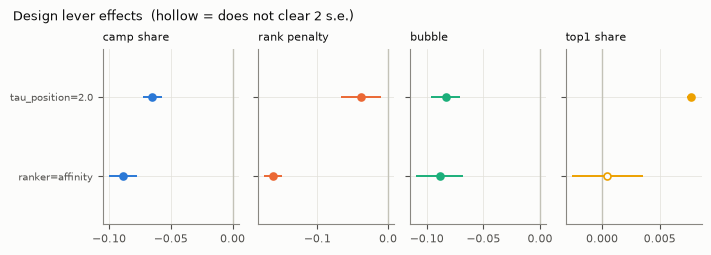

In [21]:
fig_lever_effects(summary_iv, outcomes=["cross_cutting_exposure.camp_share",
                                        "cross_cutting_exposure.rank_penalty",
                                        "feed_narrowing.bubble",
                                        "voice_inequality.top1_share"])

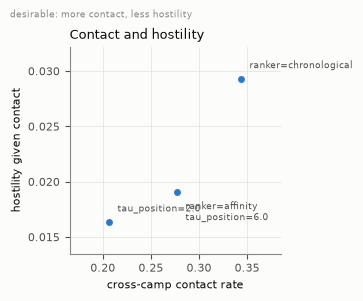

In [22]:
fig_contact_vs_hostility(summary_iv)

## 14. Users, the network, and what each of them was shown

Everything above aggregates. A Gini and a camp share are the results, but they
are also unfalsifiable-looking until you can open one up and look at a person.
`user_table` is one row per user — traits, camp, degree, what they posted, what
attention they got, how much of their feed they engaged with.

`feed_composition` then asks the question the aggregates cannot: **how did what
each user saw compare to what existed?** For every exposure it draws a post
published in the *same tick* at random and measures the distance to that
instead. `bubble = feed_dist - world_dist` is negative when the feed is closer
to the viewer than the world is — the filter-bubble effect, in stance units,
per person.

That baseline is deliberately "what existed", not "what the ranker was offered".
The candidate set is not persisted (spec §3.5 keeps a sampled exposure log, not
a feed log), and a weaker counterfactual stated plainly beats a stronger one
quietly substituted.

In [23]:
from discourse_lab.users import audience_summary, feed_composition, user_table

users = user_table(handle_norm, pop, graph, lex)
show(users.head(8), precision=2)

| user | archetype | camp | stance_provision | stance_openness | stance_institutional trust | activity | prominence | reply_prop | contrarianism | credulity | follows | followers | posts | replies | attention | seen | follower_share | engaged_share |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 0 | poster | 1 | 0.87 | 0.44 | 0.26 | 8.01 | 1.32 | 0.79 | 0.18 | 0.57 | 44 | 25 | 3 | 0 | 3 | 13 | 1.00 | 0.00 |
| 1 | lurker | 1 | -0.01 | 0.66 | 0.58 | 0.40 | 1.15 | 0.68 | 0.17 | 0.58 | 38 | 35 | 1 | 0 | 5 | 13 | 1.00 | 0.15 |
| 2 | lurker | 0 | 0.50 | -0.36 | 0.39 | 0.09 | 1.05 | 0.47 | 0.27 | 0.59 | 33 | 11 | 0 | 0 | 0 | 10 | 1.00 | 0.00 |
| 3 | lurker | 1 | -0.41 | 0.70 | -0.06 | 0.06 | 1.40 | 0.69 | 0.02 | 0.42 | 41 | 22 | 0 | 0 | 0 | 6 | 1.00 | 0.00 |
| 4 | firebrand | 1 | 0.32 | 0.87 | -0.33 | 1.94 | 1.23 | 0.47 | 0.52 | 0.20 | 37 | 47 | 1 | 1 | 9 | 12 | 1.00 | 0.00 |
| 5 | newcomer | 1 | -0.20 | 0.64 | -0.25 | 9.35 | 1.33 | 0.67 | 0.62 | 0.42 | 39 | 7 | 4 | 0 | 11 | 20 | 1.00 | 0.10 |
| 6 | poster | 1 | -0.54 | 0.60 | 0.35 | 1.60 | 1.07 | 0.68 | 0.11 | 0.37 | 46 | 29 | 1 | 0 | 0 | 13 | 1.00 | 0.00 |
| 7 | poster | 0 | 0.53 | -0.75 | -0.17 | 1.97 | 1.31 | 0.50 | 0.23 | 0.50 | 42 | 45 | 1 | 0 | 9 | 13 | 1.00 | 0.08 |

In [24]:
feeds = feed_composition(handle_norm, pop, lex)
print(f"feed  {feeds['feed_dist'].mean():.3f}   "
      f"world {feeds['world_dist'].mean():.3f}   "
      f"bubble {feeds['bubble'].mean():+.3f}")
print(f"topic entropy: feed {feeds['feed_topic_entropy'].mean():.3f}  "
      f"vs world {feeds['world_topic_entropy'].mean():.3f}")
show(audience_summary(users, feeds), precision=2)

feed  0.783   world 0.972   bubble -0.190
topic entropy: feed 1.250  vs world 1.696


| archetype | n | seen | posts | attention | feed_dist | world_dist | bubble | feed_entropy |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| firebrand | 48 | 15.35 | 1.40 | 6.06 | 0.79 | 0.98 | -0.18 | 1.36 |
| institution | 14 | 15.79 | 1.79 | 8.93 | 0.71 | 0.91 | -0.19 | 1.32 |
| lurker | 206 | 14.48 | 0.57 | 3.53 | 0.80 | 0.99 | -0.19 | 1.29 |
| newcomer | 59 | 16.39 | 1.54 | 8.24 | 0.80 | 0.99 | -0.19 | 1.38 |
| poster | 151 | 15.53 | 3.48 | 18.01 | 0.80 | 0.98 | -0.18 | 1.37 |

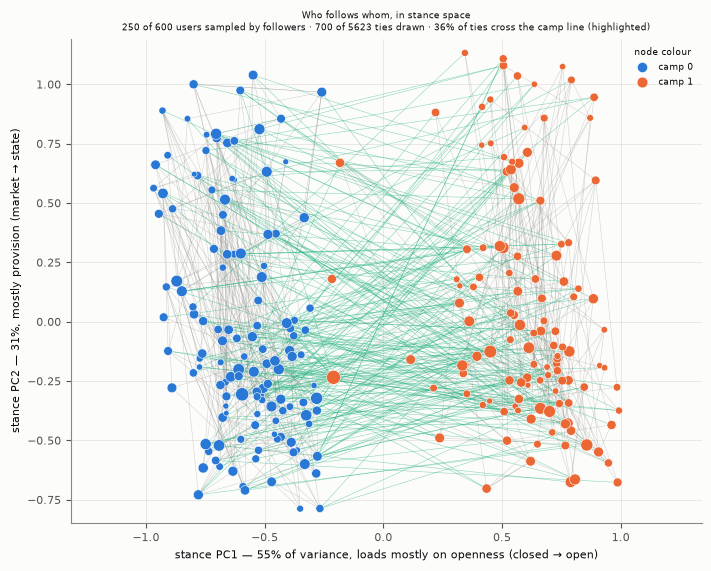

In [25]:
from discourse_lab.viz import fig_feed_mirror, fig_user_network

# positions are the first two principal components of stance, so a node's
# place on the plot *is* its ideological position — unlike a force-directed
# layout, where two nodes are adjacent because the solver put them there
fig_user_network(graph, users, lex)

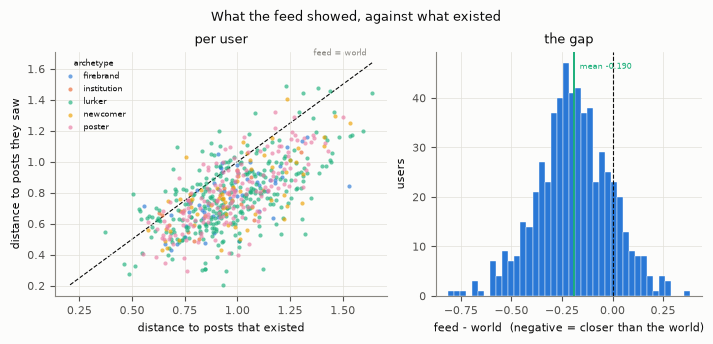

In [26]:
fig_feed_mirror(feeds, users, by="archetype")

## 15. Figures and tables

Everything above, written to `dlab/figures/` and `dlab/tables/` as vector PDF
(for a paper) and PNG (for here), with each table in both LaTeX booktabs and
Markdown. Requires the optional extra: `pip install -e ".[viz]"`.

`fig_metric_trajectories` takes the run **and its matched null** — spec §5.3
makes that comparison mandatory, so there is no way to plot the model alone.

figures -> /home/user/Network-Simulation/notebooks/dlab_demo/figures
tables  -> /home/user/Network-Simulation/notebooks/dlab_demo/tables


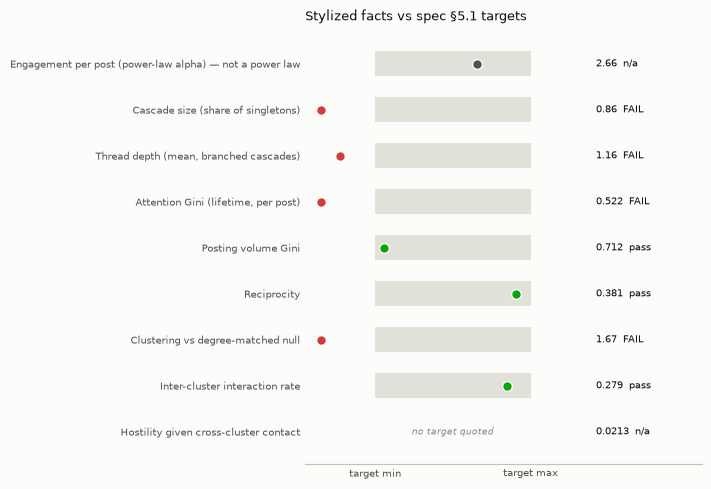

In [27]:
from discourse_lab.viz import (
    fig_calibration, fig_cascade_sizes, fig_engagement_ccdf,
    fig_degree_ccdf, fig_lorenz, fig_metric_trajectories, save_figure,
)

# the matched null: same population, same graph, same seed — only the kernel
# differs, which is what makes the difference attributable to the kernel
cfg_null = dataclasses.replace(cfg, dynamics=dataclasses.replace(cfg.dynamics, kernel="null"))
cached_run(cfg_null, seed=SEED, persist=("posts",))
handle_null = load_run(cfg_null, seed=SEED)

posts = handle.posts()
engagement = posts["engagement_count"].to_numpy().astype(float)
post_authors = posts.filter(posts["kind"] == "post")["author"].to_numpy()
per_user = np.bincount(post_authors, minlength=cfg.population.n_users).astype(float)

figures = {
    "fig_calibration": fig_calibration(report),
    "fig_metric_trajectories": fig_metric_trajectories(handle, handle_null),
    "fig_engagement_ccdf": fig_engagement_ccdf(engagement),
    "fig_cascade_sizes": fig_cascade_sizes(posts["root"].to_numpy()),
    "fig_lorenz": fig_lorenz({"attention (per post)": engagement,
                              "posting volume (per user)": per_user}),
    "fig_degree_ccdf": fig_degree_ccdf(graph.csr),
}
for name, figure in figures.items():
    save_figure(figure, name)

tables.save_table(facts, "T1_stylized_facts",
                  caption="Stylized facts against spec 5.1 targets.", label="tab:facts")
tables.save_table(tables.experiment_effects_table(rows), "T2_experiment1_effects",
                  caption="Experiment 1 effects against the matched null.", label="tab:effects")
tables.save_table(tables.provenance_table(handle.meta), "T3_provenance",
                  caption="Run provenance.", label="tab:provenance")

print("figures ->", figures_dir())
print("tables  ->", tables_dir())
figures["fig_calibration"]